In [ ]:
import sys
import os
sys.path.append(os.path.abspath('..'))

import pandas as pd
from eval_utils import extract_evaluation_data, specificity_multiclass, plot_confusion_matrix
from sklearn.metrics import accuracy_score, classification_report

# 1. Load raw results
raw_df = pd.read_json("../results/ablation/gemini.jsonl", lines=True)

# 2. Extract and normalize evaluation data (target_agent='diagnose' for ablation)
df = extract_evaluation_data(raw_df, target_agent="diagnose")
df.dropna(subset=["diagnosis"], inplace=True)

print(f"Loaded {len(df)} cases for evaluation.")
df.head(5)

Loaded 289 cases for evaluation.


,image_path,diagnosis,reasoning,ground_truth,confidence,differential,retrieved_cases
0,ISIC_0025686,Melanoma,The Triage Agent classified this as a 'Melanoc...,Nevus,High,None,None
1,ISIC_0031196,Actinic Keratosis,The Triage Agent classified this lesion as 'Ke...,Pigmented benign keratosis,High,None,None
2,ISIC_0030535,Melanoma,The Triage Agent correctly classified this les...,Nevus,High,None,None
3,ISIC_0024994,Dermatofibroma,The triage agent classified the lesion as 'Fib...,Dermatofibroma,Medium,None,None
4,ISIC_0024944,Melanoma,The triage agent's classification of 'Melanocy...,Nevus,High,None,None


In [4]:
print("Diagnosis distribution:")
print(df["diagnosis"].value_counts())

Diagnosis distribution:
diagnosis
Melanoma                      149
Basal cell carcinoma           44
Pigmented benign keratosis     42
Nevus                          26
Actinic Keratosis              14
Dermatofibroma                  7
Squamous cell carcinoma         7
Name: count, dtype: int64


In [5]:
y_true = df["ground_truth"]
y_pred = df["diagnosis"]

accuracy = accuracy_score(y_true, y_pred)
spec_results = specificity_multiclass(y_true, y_pred)
report = classification_report(y_true, y_pred, digits=4)

print(f"✅ Overall Accuracy: {accuracy:.4f}\n")
print(f"📊 Macro-average Specificity: {spec_results['macro_avg']:.4f}")
print(f"📈 Weighted-average Specificity: {spec_results['weighted_avg']:.4f}")
print("\n📊 Classification Report:\n", report)

✅ Overall Accuracy: 0.3875

📊 Macro-average Specificity: 0.9000
📈 Weighted-average Specificity: 0.9124

📊 Classification Report:
                             precision    recall  f1-score   support

         Actinic Keratosis     0.0714    0.0667    0.0690        15
      Basal cell carcinoma     0.3864    0.6800    0.4928        25
            Dermatofibroma     1.0000    0.4375    0.6087        16
                  Melanoma     0.2685    1.0000    0.4233        40
                     Nevus     0.9615    0.1894    0.3165       132
Pigmented benign keratosis     0.5000    0.5526    0.5250        38
   Squamous cell carcinoma     0.1429    0.0435    0.0667        23

                  accuracy                         0.3875       289
                 macro avg     0.4758    0.4242    0.3574       289
              weighted avg     0.6459    0.3875    0.3574       289



Displaying Confusion Matrix for Initial Diagnosis...


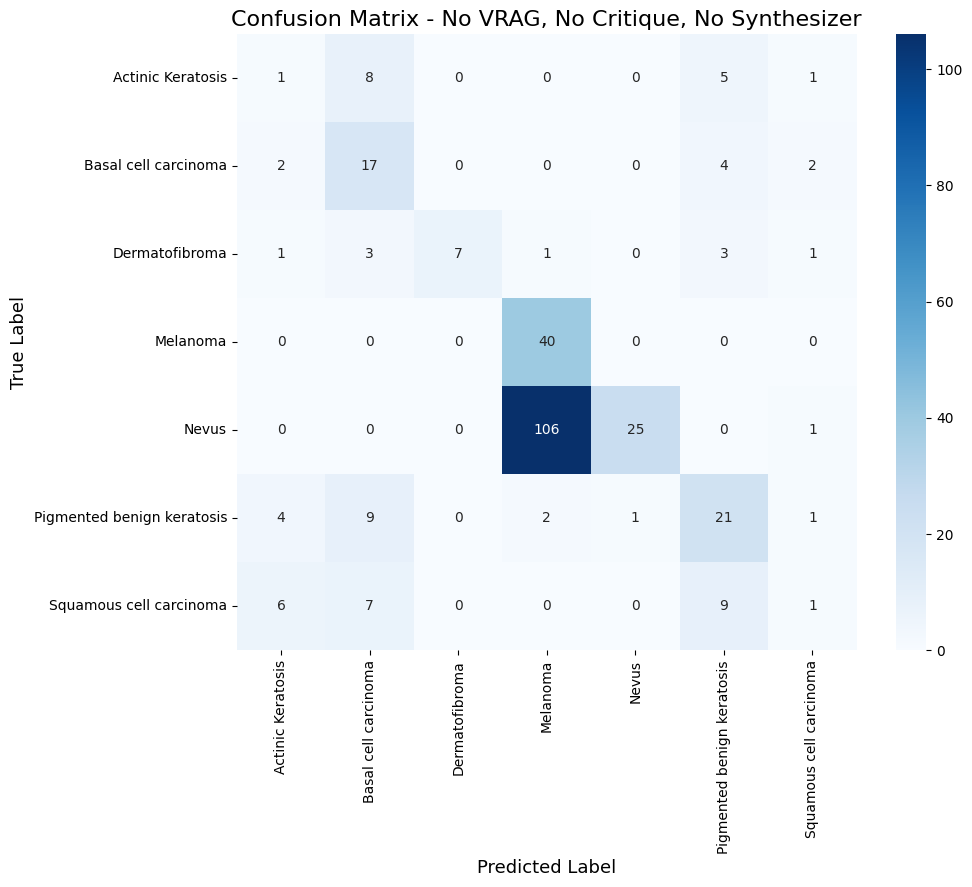

In [6]:
class_labels = ['Actinic Keratosis', 'Basal cell carcinoma', 'Dermatofibroma', 'Melanoma', 'Nevus', 'Pigmented benign keratosis', 'Squamous cell carcinoma']
print("Displaying Confusion Matrix for Initial Diagnosis...")
plot_confusion_matrix(y_true, 
                      y_pred, 
                      class_labels=class_labels, 
                      title='Confusion Matrix - No VRAG, No Critique, No Synthesizer')
